# Actividad 2 — Filtros Espaciales y Morfológicos
## Visión Artificial · UNIR · MIA
**Dominio:** Detección de grietas en concreto (SDNET2018)  
**Reto:** Destacar estructuras lineales finas sobre fondos texturizados, refinar segmentaciones y realzar bordes  
**Imágenes:** `001-130.jpg` · `001-145.jpg` · `010-123.jpg`

---
### Pipeline completo
```
Imagen original
      ↓
[0] Conversión a escala de grises
      ↓
[1] Suavizado Gaussiano  — atenuar ruido preservando la grieta
      ↓
[2] Realce de bordes     — Sobel vs. Laplaciano
      ↓
[3] Binarización         — umbralización de Otsu
      ↓
[4] Morfología           — Apertura · Cierre · Erosión · Dilatación
      ↓
[5] Top Hat morfológico  — extracción de estructuras finas
      ↓
[6] Métricas comparativas
```


---
## Sección 0 — Importaciones y carga de imágenes

Trabajamos en **escala de grises** porque las grietas son diferencias de intensidad, no de color.
Convertir a gris reduce dimensionalidad sin perder información relevante para este problema.

> **Nota:** OpenCV carga en BGR. Para mostrar en matplotlib usamos `cv2.COLOR_BGR2RGB`.
> Para procesar usamos `cv2.COLOR_BGR2GRAY`.


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.filters import threshold_otsu
from skimage.metrics import peak_signal_noise_ratio as psnr
import warnings
warnings.filterwarnings("ignore")


IMAGENES = {
    "Grieta sutil (001-130)":      "001-130.jpg",
    "Grieta visible (001-145)":    "001-145.jpg",
    "Grieta ramificada (010-123)": "010-123.jpg",
}

imgs_rgb  = {}
imgs_gray = {}

for nombre, ruta in IMAGENES.items():
    bgr = cv2.imread(ruta)
    if bgr is None:
        print(f"[!] No se encontró: {ruta}")
        continue
    imgs_rgb[nombre]  = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    imgs_gray[nombre] = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)

print(f"Imágenes cargadas: {len(imgs_gray)}")
for n, img in imgs_gray.items():
    print(f"  {n}: {img.shape} px  |  media={img.mean():.1f}  std={img.std():.1f}")


Imágenes cargadas: 3
  Grieta sutil (001-130): (256, 256) px  |  media=108.6  std=19.8
  Grieta visible (001-145): (256, 256) px  |  media=104.6  std=14.6
  Grieta ramificada (010-123): (256, 256) px  |  media=144.5  std=20.3


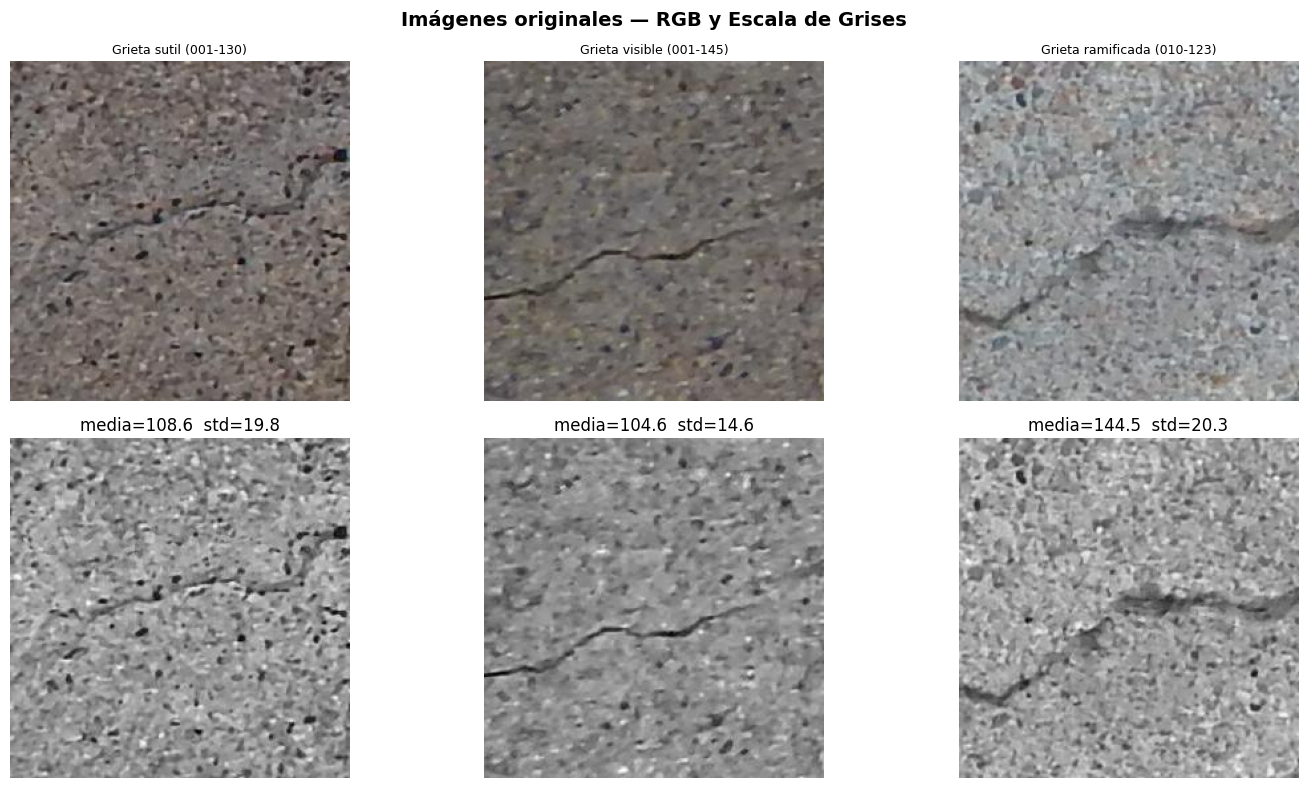

In [3]:
# ── Visualización inicial ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Imágenes originales — RGB y Escala de Grises", fontsize=14, fontweight="bold")

for col, (nombre, img_rgb) in enumerate(imgs_rgb.items()):
    axes[0, col].imshow(img_rgb)
    axes[0, col].set_title(nombre, fontsize=9)
    axes[0, col].axis("off")

    gray = imgs_gray[nombre]
    axes[1, col].imshow(gray, cmap="gray")
    axes[1, col].set_title(f"media={gray.mean():.1f}  std={gray.std():.1f}")
    axes[1, col].axis("off")

axes[0, 0].set_ylabel("Color (RGB)", fontsize=10)
axes[1, 0].set_ylabel("Gris", fontsize=10)
plt.tight_layout()
plt.savefig("fig_00_originales.png", dpi=150, bbox_inches="tight")
plt.show()


---
## Sección 1 — Suavizado Gaussiano

### ¿Por qué primero suavizar?

El concreto tiene textura rugosa: variaciones de intensidad que el algoritmo confunde con grietas.
Sin suavizado, el detector de bordes produce falsos positivos por toda la textura.

El **Gaussian Blur** convoluciona la imagen con un kernel gaussiano: cada píxel se reemplaza
por un promedio ponderado de sus vecinos, donde los más cercanos pesan más.
Resultado: ruido y textura (alta frecuencia) se atenúan; la grieta (estructura mayor) se conserva.

**Kernel gaussiano 2D:**

$$G(x,y) = \frac{1}{2\pi\sigma^2}\,e^{-\frac{x^2+y^2}{2\sigma^2}}$$

- **σ:** controla el ancho. Mayor σ = más suavizado.
- **k:** tamaño del kernel, siempre impar. Regla práctica: `k ≈ 6σ + 1`.

**Comparamos:** k=3 (leve), k=7 (moderado), k=15 (agresivo).  
Pregunta clave: ¿en qué punto el suavizado empieza a borrar la grieta?


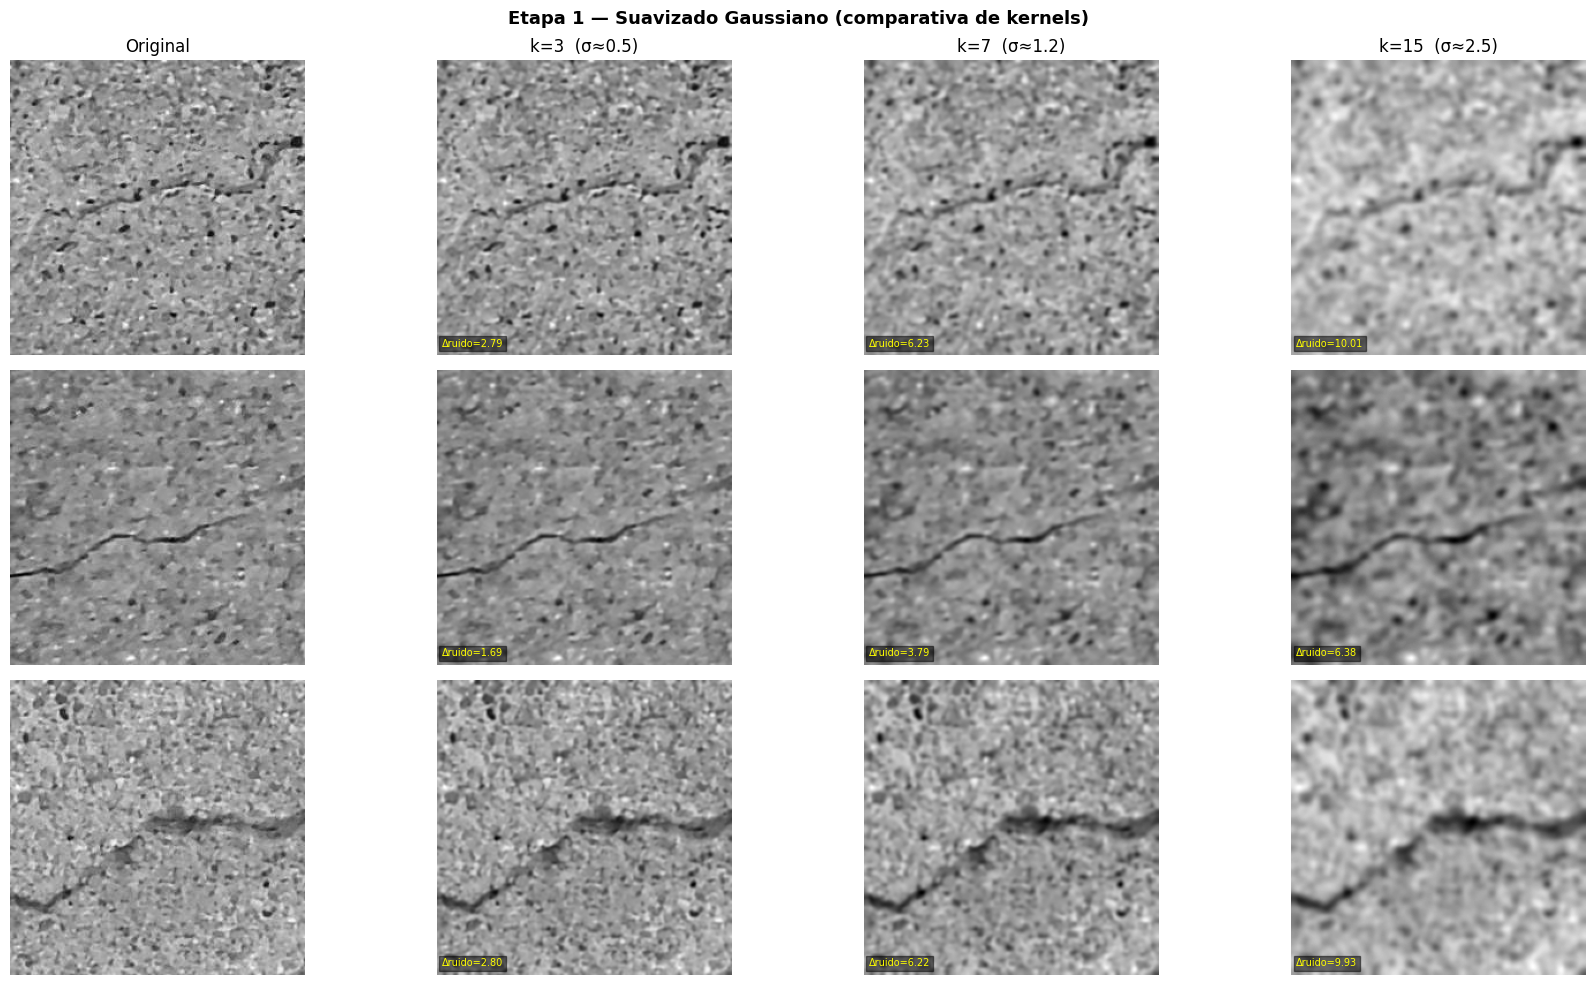

Kernel seleccionado para el pipeline: k=7
Justificación: atenúa la textura rugosa del concreto sin difuminar
los bordes de la grieta, que son transiciones de mayor escala espacial.


In [4]:
# ── Gaussian Blur — tres niveles de kernel ────────────────────────────────
KERNELS = [3, 7, 15]
suavizadas = {n: {} for n in imgs_gray}

fig, axes = plt.subplots(len(imgs_gray), len(KERNELS) + 1, figsize=(18, 10))
fig.suptitle("Etapa 1 — Suavizado Gaussiano (comparativa de kernels)", fontsize=13, fontweight="bold")

for fila, (nombre, gray) in enumerate(imgs_gray.items()):
    axes[fila, 0].imshow(gray, cmap="gray")
    axes[fila, 0].set_ylabel(nombre, fontsize=8)
    if fila == 0: axes[fila, 0].set_title("Original")
    axes[fila, 0].axis("off")

    for col, k in enumerate(KERNELS, start=1):
        blur = cv2.GaussianBlur(gray, (k, k), sigmaX=0)
        suavizadas[nombre][k] = blur
        diff_media = cv2.absdiff(gray, blur).mean()

        axes[fila, col].imshow(blur, cmap="gray")
        if fila == 0:
            axes[fila, col].set_title(f"k={k}  (σ≈{k/6:.1f})")
        axes[fila, col].axis("off")
        axes[fila, col].text(4, gray.shape[0]-8, f"Δruido={diff_media:.2f}",
            color="yellow", fontsize=7, bbox=dict(facecolor="black", alpha=0.5, pad=2))

plt.tight_layout()
plt.savefig("fig_01_gaussiano.png", dpi=150, bbox_inches="tight")
plt.show()

# Selección para el resto del pipeline
K_SEL = 7
print(f"Kernel seleccionado para el pipeline: k={K_SEL}")
print("Justificación: atenúa la textura rugosa del concreto sin difuminar")
print("los bordes de la grieta, que son transiciones de mayor escala espacial.")


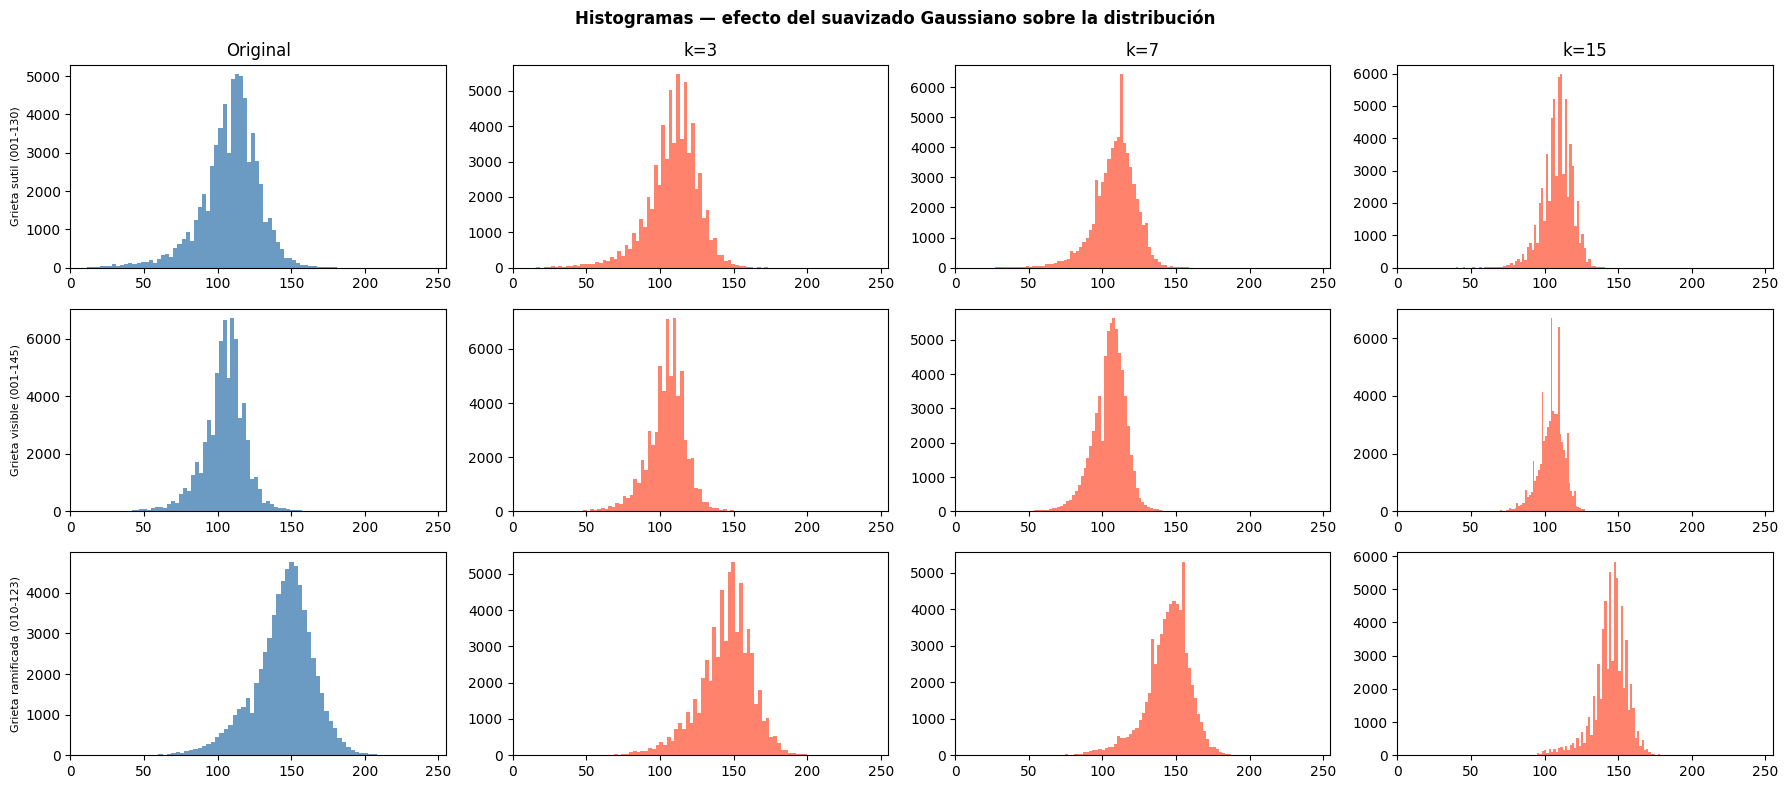

In [5]:
# ── Histogramas antes y después del suavizado ─────────────────────────────
fig, axes = plt.subplots(len(imgs_gray), len(KERNELS) + 1, figsize=(18, 8))
fig.suptitle("Histogramas — efecto del suavizado Gaussiano sobre la distribución", fontsize=12, fontweight="bold")

for fila, (nombre, gray) in enumerate(imgs_gray.items()):
    axes[fila, 0].hist(gray.ravel(), bins=64, color="steelblue", alpha=0.8)
    axes[fila, 0].set_xlim(0, 255)
    axes[fila, 0].set_ylabel(nombre, fontsize=8)
    if fila == 0: axes[fila, 0].set_title("Original")

    for col, k in enumerate(KERNELS, start=1):
        blur = suavizadas[nombre][k]
        axes[fila, col].hist(blur.ravel(), bins=64, color="tomato", alpha=0.8)
        axes[fila, col].set_xlim(0, 255)
        if fila == 0: axes[fila, col].set_title(f"k={k}")

plt.tight_layout()
plt.savefig("fig_01b_hist_gaussiano.png", dpi=150, bbox_inches="tight")
plt.show()


---
## Sección 2 — Realce de bordes: Sobel vs. Laplaciano

Una grieta es una transición brusca de intensidad. Esas transiciones = **bordes**.

| Operador | Base matemática | Resultado | Sensibilidad al ruido |
|---|---|---|---|
| **Sobel** | Primera derivada (gradiente) | Bordes gruesos, con dirección | Media |
| **Laplaciano** | Segunda derivada | Bordes más finos, isotrópico | Alta |

### Sobel

Dos kernels de 3×3, uno por dirección:

$$G_x = \begin{bmatrix}-1&0&+1\\-2&0&+2\\-1&0&+1\end{bmatrix}*I
\qquad
G_y = \begin{bmatrix}-1&-2&-1\\0&0&0\\+1&+2&+1\end{bmatrix}*I$$

$$|G| = \sqrt{G_x^2 + G_y^2} \qquad \theta = \arctan\!\left(\frac{G_y}{G_x}\right)$$

**Regla mnemotécnica:** Gx detecta cambios horizontales de intensidad → resalta bordes **verticales**.

### Laplaciano

$$\nabla^2 I = \frac{\partial^2 I}{\partial x^2} + \frac{\partial^2 I}{\partial y^2}
\qquad \Rightarrow \qquad
L = \begin{bmatrix}0&1&0\\1&-4&1\\0&1&0\end{bmatrix}$$

Cruza por cero justo en el borde → localización más precisa, pero amplifica ruido.
**Por eso siempre se aplica después del Gaussiano.**


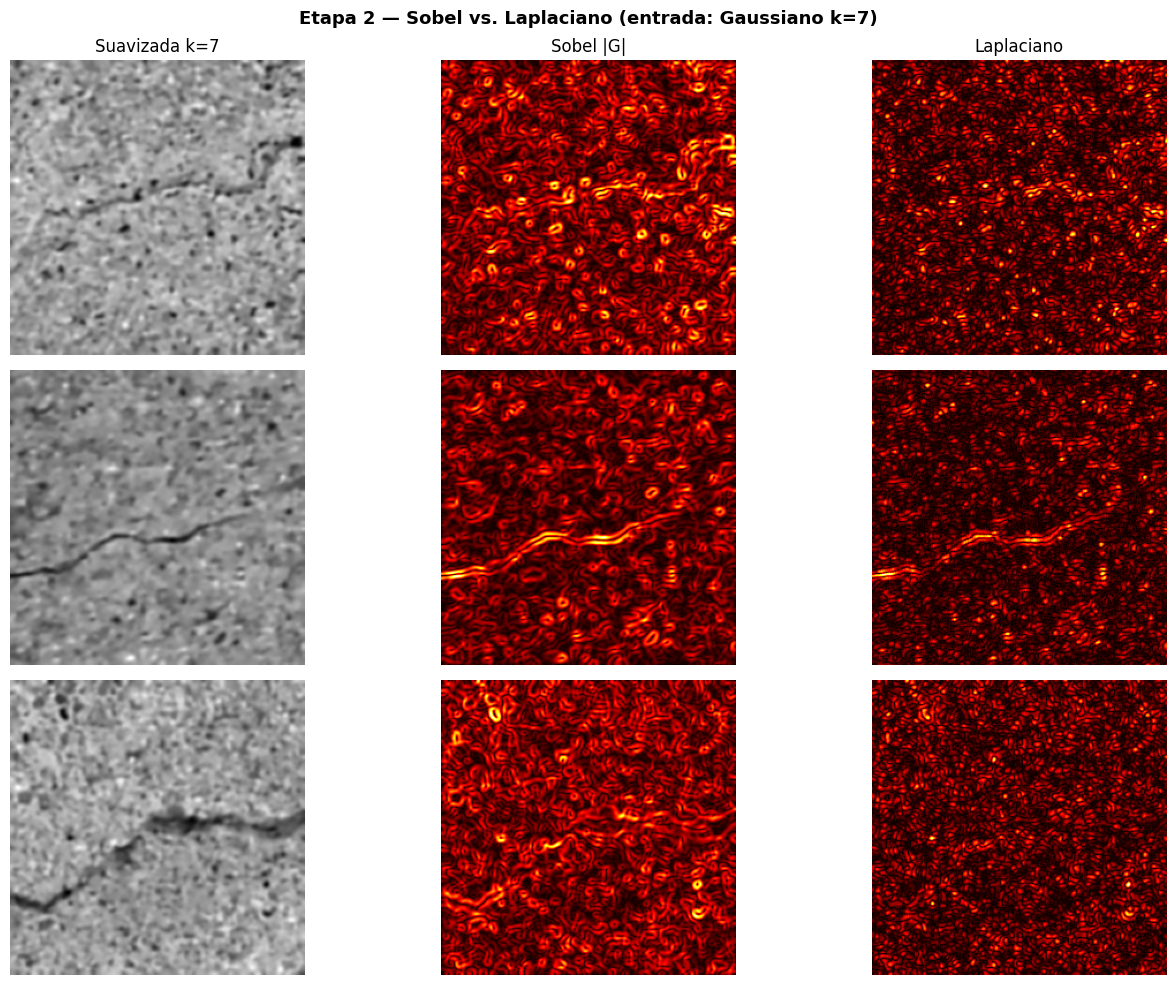

In [6]:
# ── Sobel y Laplaciano sobre imagen suavizada (k=7) ──────────────────────
bordes_sobel      = {}
bordes_laplaciano = {}

fig, axes = plt.subplots(len(imgs_gray), 3, figsize=(14, 10))
fig.suptitle("Etapa 2 — Sobel vs. Laplaciano (entrada: Gaussiano k=7)", fontsize=13, fontweight="bold")

for fila, (nombre, gray) in enumerate(imgs_gray.items()):
    blur = suavizadas[nombre][K_SEL]

    # Sobel — magnitud del gradiente
    Gx  = cv2.Sobel(blur, cv2.CV_64F, 1, 0, ksize=3)
    Gy  = cv2.Sobel(blur, cv2.CV_64F, 0, 1, ksize=3)
    mag = np.sqrt(Gx**2 + Gy**2)
    sobel = np.uint8(255 * mag / mag.max())
    bordes_sobel[nombre] = sobel

    # Laplaciano
    lap_abs = np.abs(cv2.Laplacian(blur, cv2.CV_64F, ksize=3))
    lap = np.uint8(255 * lap_abs / lap_abs.max())
    bordes_laplaciano[nombre] = lap

    for col, (titulo, img, cm) in enumerate([
        ("Suavizada k=7", blur, "gray"),
        ("Sobel |G|",     sobel, "hot"),
        ("Laplaciano",    lap,   "hot"),
    ]):
        axes[fila, col].imshow(img, cmap=cm)
        if fila == 0: axes[fila, col].set_title(titulo)
        axes[fila, col].axis("off")
    axes[fila, 0].set_ylabel(nombre, fontsize=8)

plt.tight_layout()
plt.savefig("fig_02_bordes.png", dpi=150, bbox_inches="tight")
plt.show()


---
## Sección 3 — Binarización: Umbralización de Otsu

Los resultados de Sobel son en escala de grises. La morfología necesita
una **imagen binaria** (exactamente 0 o 255).

Dado un umbral τ, cada píxel se clasifica:

$$B(x,y) = \begin{cases}255 & \text{si } I(x,y) > \tau \\ 0 & \text{si } I(x,y) \leq \tau\end{cases}$$

**Otsu** calcula automáticamente el τ que maximiza la **varianza entre clases**
(fondo vs. grieta). No hay que elegirlo a mano — lo deduce del histograma.
Funciona bien cuando el histograma es bimodal, que es nuestro caso.


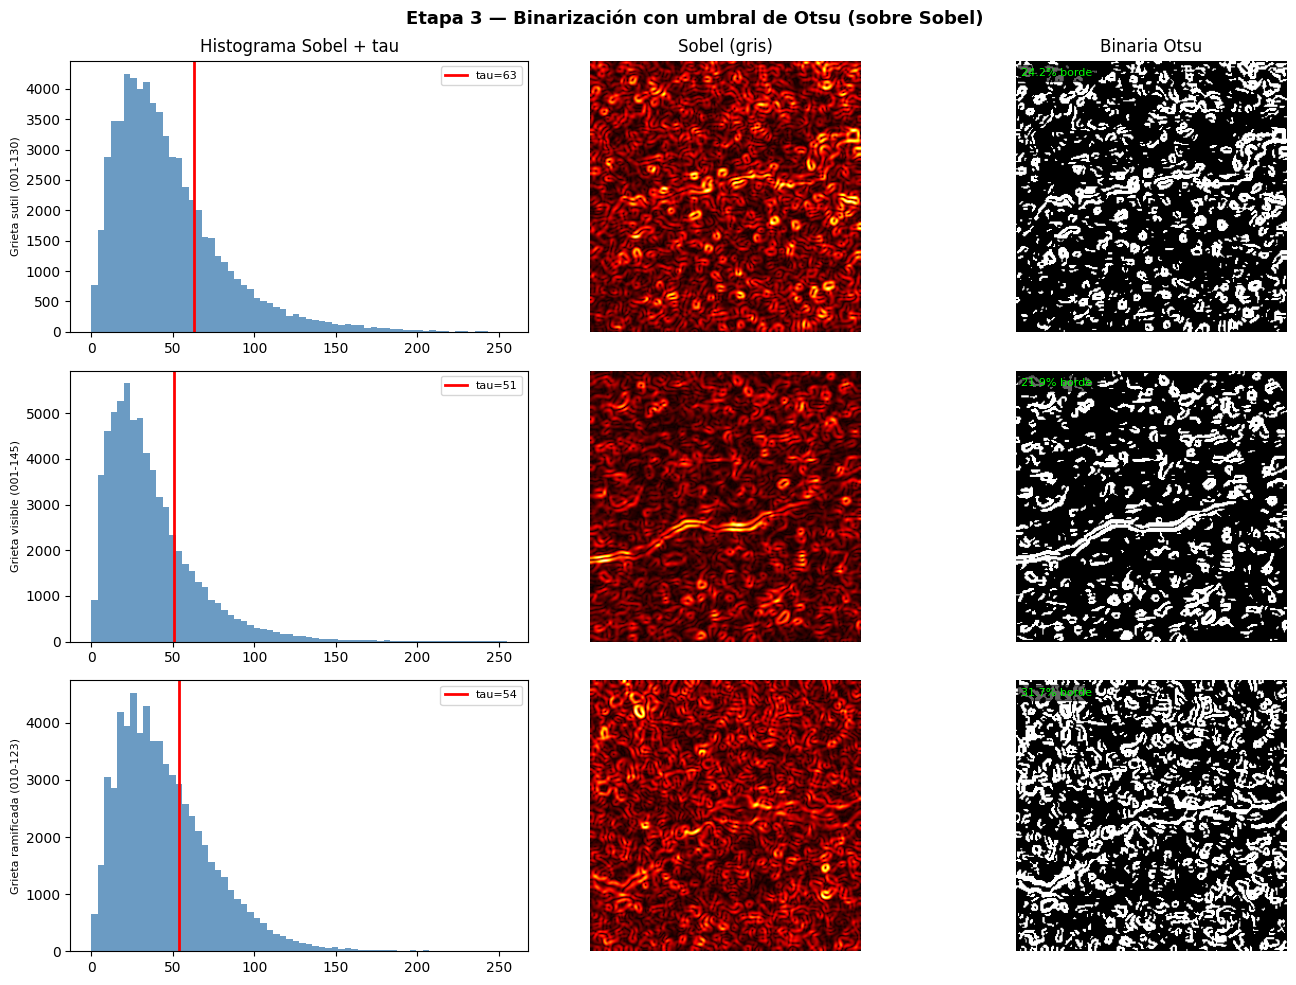

In [7]:
# ── Umbralización de Otsu sobre resultado Sobel ───────────────────────────
binarias = {}

fig, axes = plt.subplots(len(imgs_gray), 3, figsize=(14, 10))
fig.suptitle("Etapa 3 — Binarización con umbral de Otsu (sobre Sobel)", fontsize=13, fontweight="bold")

for fila, (nombre, gray) in enumerate(imgs_gray.items()):
    sobel = bordes_sobel[nombre]
    tau   = threshold_otsu(sobel)
    bin_  = (sobel > tau).astype(np.uint8) * 255
    binarias[nombre] = bin_
    pct = bin_.mean() / 255 * 100

    axes[fila, 0].hist(sobel.ravel(), bins=64, color="steelblue", alpha=0.8)
    axes[fila, 0].axvline(tau, color="red", lw=2, label=f"tau={tau:.0f}")
    axes[fila, 0].legend(fontsize=8)
    axes[fila, 0].set_ylabel(nombre, fontsize=8)
    if fila == 0: axes[fila, 0].set_title("Histograma Sobel + tau")

    axes[fila, 1].imshow(sobel, cmap="hot")
    if fila == 0: axes[fila, 1].set_title("Sobel (gris)")
    axes[fila, 1].axis("off")

    axes[fila, 2].imshow(bin_, cmap="gray")
    if fila == 0: axes[fila, 2].set_title("Binaria Otsu")
    axes[fila, 2].axis("off")
    axes[fila, 2].text(4, 14, f"{pct:.1f}% borde", color="lime", fontsize=8,
                       bbox=dict(facecolor="black", alpha=0.6, pad=2))

plt.tight_layout()
plt.savefig("fig_03_otsu.png", dpi=150, bbox_inches="tight")
plt.show()


---
## Sección 4 — Operaciones Morfológicas

La binaria después de Otsu tiene dos problemas:
1. **Ruido puntual:** píxeles blancos aislados que no son grieta.
2. **Huecos:** fragmentos de la grieta que quedaron negros.

Las operaciones morfológicas usan un **elemento estructurante (SE)**
como sonda para modificar la forma de los objetos.

| Operación | Efecto |
|---|---|
| **Erosión** $I \ominus SE$ | Encoge — elimina puntitos de ruido |
| **Dilatación** $I \oplus SE$ | Expande — reconecta fragmentos |
| **Apertura** = Erosión → Dilatación | Elimina objetos pequeños |
| **Cierre** = Dilatación → Erosión | Rellena huecos pequeños |

La **forma** del SE importa para grietas lineales:
- Disco: isotrópico, sin preferencia de dirección
- Rectangular horizontal: favorece estructuras horizontales
- Rectangular vertical: favorece estructuras verticales


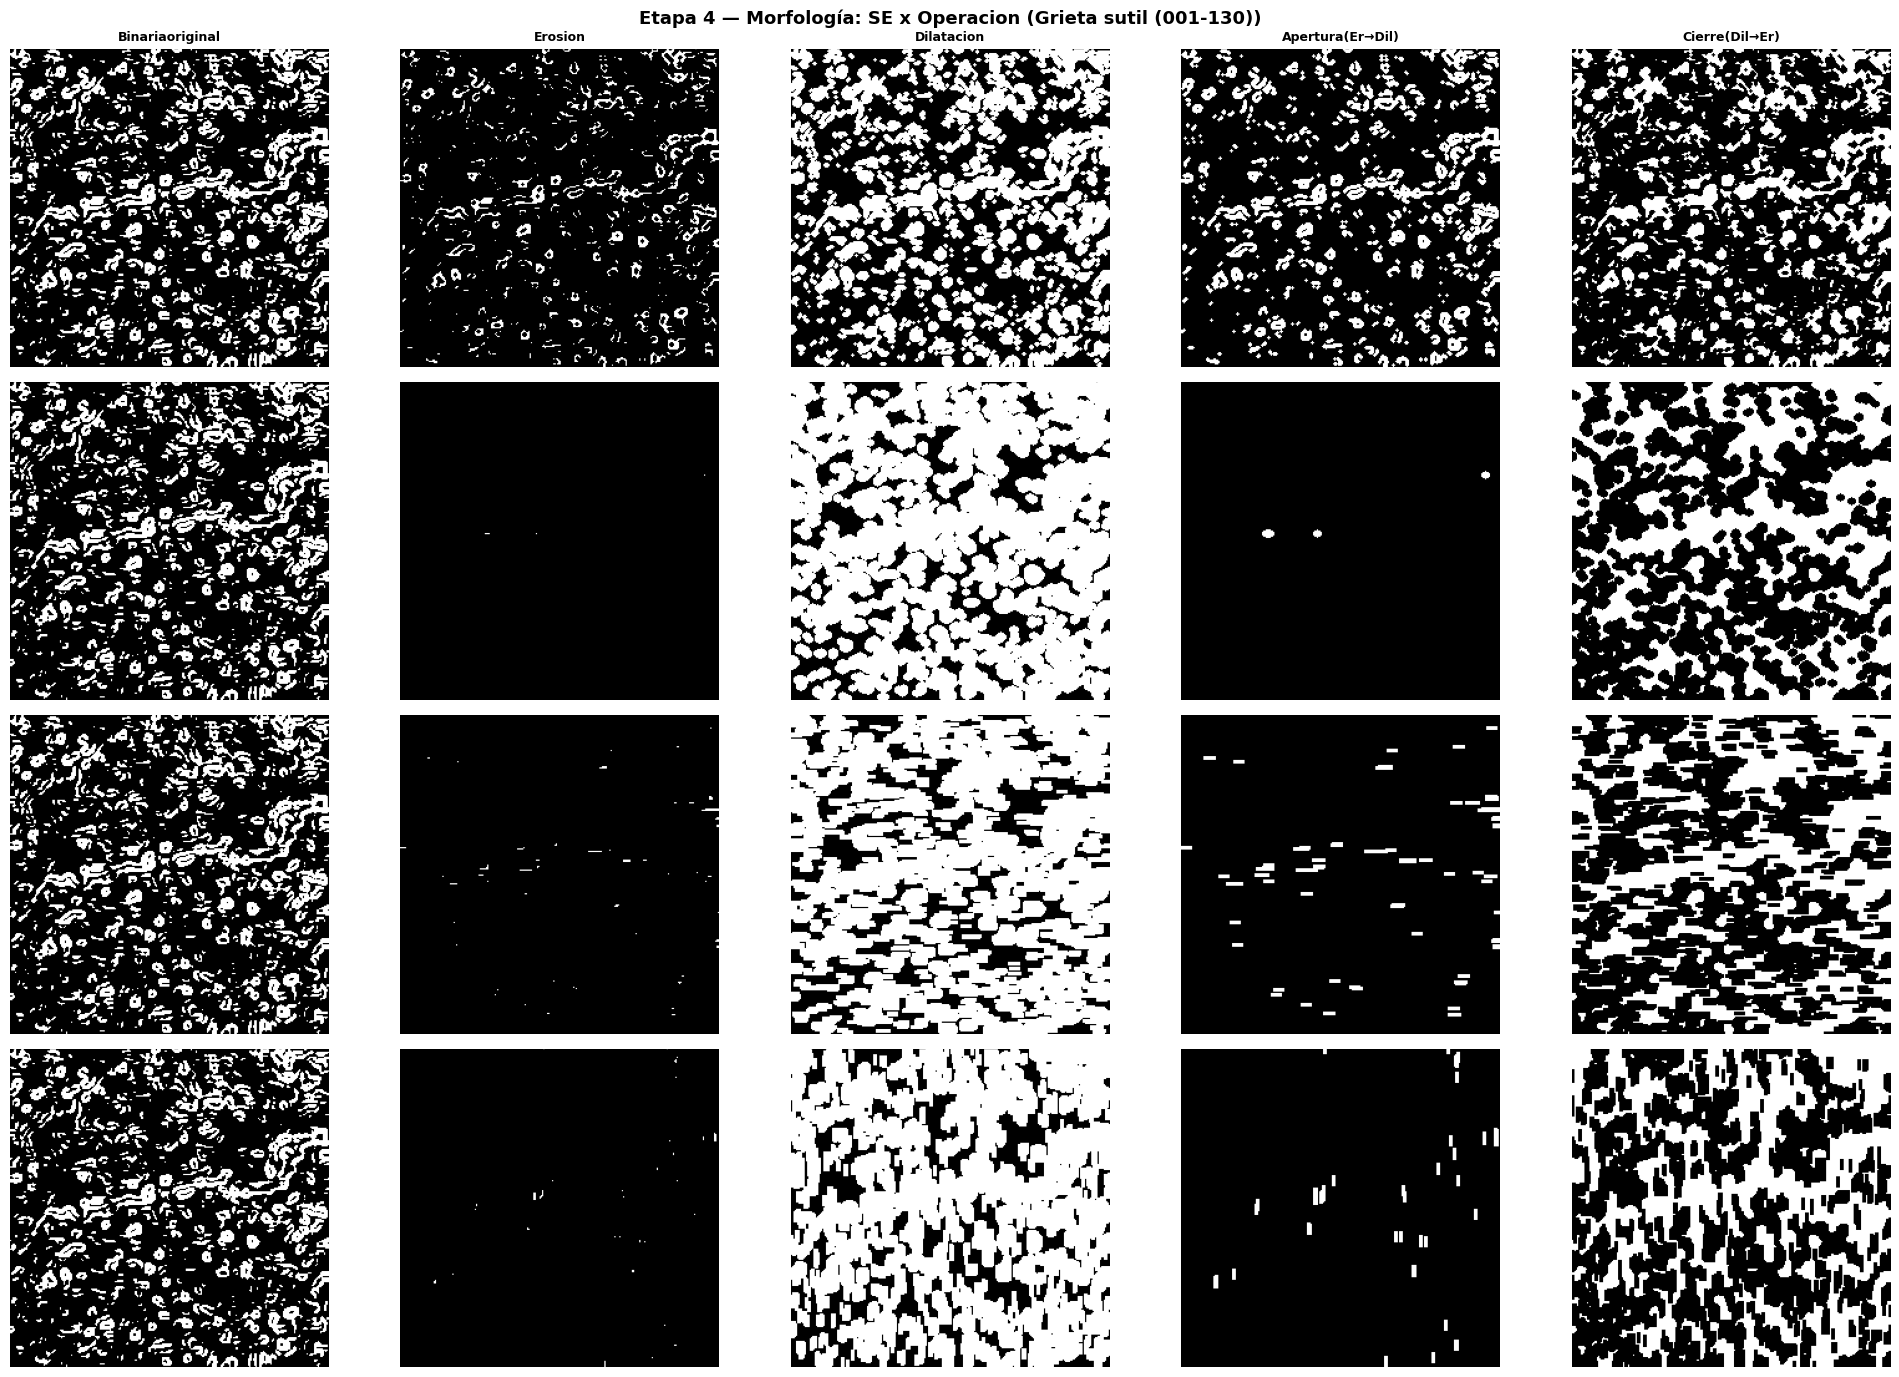

In [10]:
# ── Comparativa de elementos estructurantes y operaciones ─────────────────
SEs = {
    "Disco 3x3":   cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3)),
    "Disco 7x7":   cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7)),
    "Rect H 9x3":  cv2.getStructuringElement(cv2.MORPH_RECT, (9, 3)),
    "Rect V 3x9":  cv2.getStructuringElement(cv2.MORPH_RECT, (3, 9)),
}

nombre_demo = list(binarias.keys())[0]
bin_demo    = binarias[nombre_demo]

fig, axes = plt.subplots(len(SEs), 5, figsize=(20, 14))
fig.suptitle(f"Etapa 4 — Morfología: SE x Operacion ({nombre_demo})", fontsize=13, fontweight="bold")

titulos_col = ["Binariaoriginal", "Erosion", "Dilatacion", "Apertura(Er→Dil)", "Cierre(Dil→Er)"]
for c, t in enumerate(titulos_col):
    axes[0, c].set_title(t, fontsize=9, fontweight="bold")

for fila, (se_nom, se) in enumerate(SEs.items()):
    ops = [
        bin_demo,
        cv2.erode(bin_demo, se),
        cv2.dilate(bin_demo, se),
        cv2.morphologyEx(bin_demo, cv2.MORPH_OPEN,  se),
        cv2.morphologyEx(bin_demo, cv2.MORPH_CLOSE, se),
    ]
    for col, img in enumerate(ops):
        axes[fila, col].imshow(img, cmap="gray")
        axes[fila, col].axis("off")
    axes[fila, 0].set_ylabel(se_nom, fontsize=9)

plt.tight_layout()
plt.savefig("fig_04_morfologia_se.png", dpi=150, bbox_inches="tight")
plt.show()


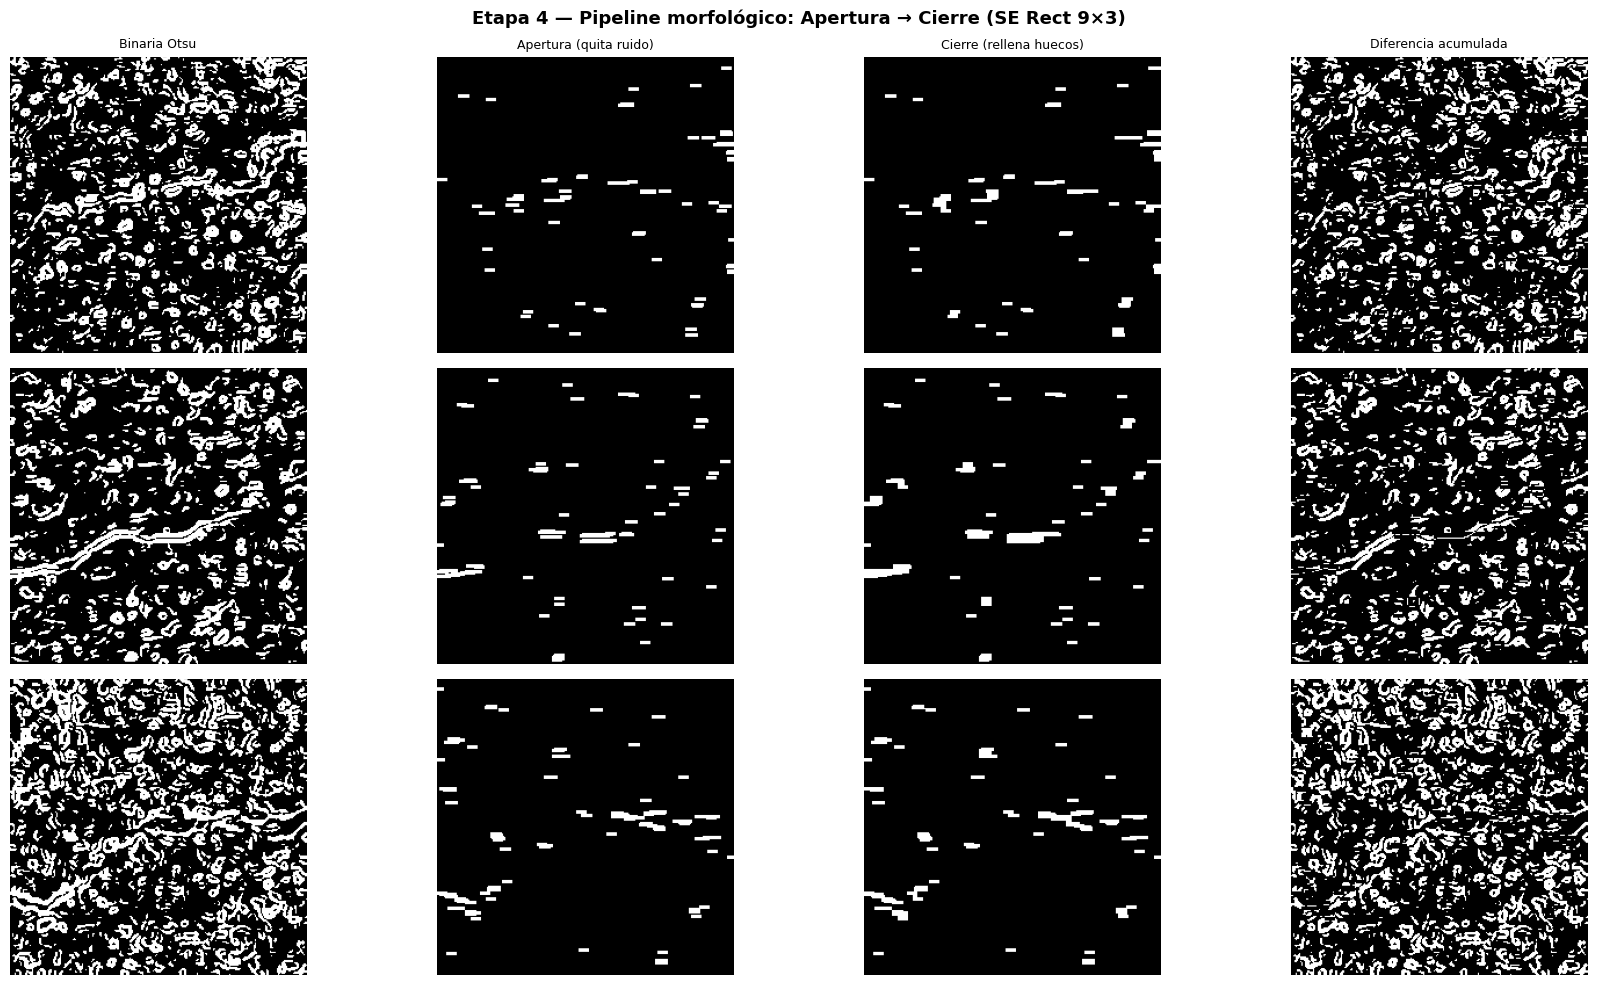

In [11]:
# ── Pipeline morfológico final: Apertura → Cierre sobre las 3 imágenes ───
# SE rectangular horizontal 9x3: favorece la morfología lineal de la grieta
# Apertura: elimina ruido puntual (píxeles aislados)
# Cierre:   rellena discontinuidades dentro de la grieta

SE_FINAL = cv2.getStructuringElement(cv2.MORPH_RECT, (9, 3))
morfologicas = {}

fig, axes = plt.subplots(len(imgs_gray), 4, figsize=(18, 10))
fig.suptitle("Etapa 4 — Pipeline morfológico: Apertura → Cierre (SE Rect 9×3)", fontsize=13, fontweight="bold")

for fila, (nombre, gray) in enumerate(imgs_gray.items()):
    bin_   = binarias[nombre]
    apertura = cv2.morphologyEx(bin_,     cv2.MORPH_OPEN,  SE_FINAL)
    cierre   = cv2.morphologyEx(apertura, cv2.MORPH_CLOSE, SE_FINAL)
    morfologicas[nombre] = cierre
    diff = cv2.absdiff(bin_, cierre)

    for col, (titulo, img) in enumerate([
        ("Binaria Otsu",           bin_),
        ("Apertura (quita ruido)", apertura),
        ("Cierre (rellena huecos)",cierre),
        ("Diferencia acumulada",   diff),
    ]):
        axes[fila, col].imshow(img, cmap="gray")
        if fila == 0: axes[fila, col].set_title(titulo, fontsize=9)
        axes[fila, col].axis("off")
    axes[fila, 0].set_ylabel(nombre, fontsize=8)

plt.tight_layout()
plt.savefig("fig_04b_morfologia_pipeline.png", dpi=150, bbox_inches="tight")
plt.show()


---
## Sección 5 — Top Hat Morfológico (operación avanzada obligatoria)

### White Top Hat

Extrae estructuras **más pequeñas que el SE** directamente sobre la imagen en gris,
sin necesidad de umbralizar primero.

$$\text{White Top Hat}(I) = I - \text{Apertura}(I)$$

**Intuición:** la Apertura con SE grande preserva el fondo pero elimina la grieta fina.
Al restar, lo que queda es exactamente la grieta — brillante sobre fondo negro.

### Black Hat

$$\text{Black Hat}(I) = \text{Cierre}(I) - I$$

Extrae estructuras **oscuras** (como una grieta oscura sobre concreto claro).

Con un SE de 25×25, cualquier estructura más delgada que 25 px queda extraída.
Las grietas del dataset SDNET2018 miden 1–5 px de ancho → perfectas para esto.


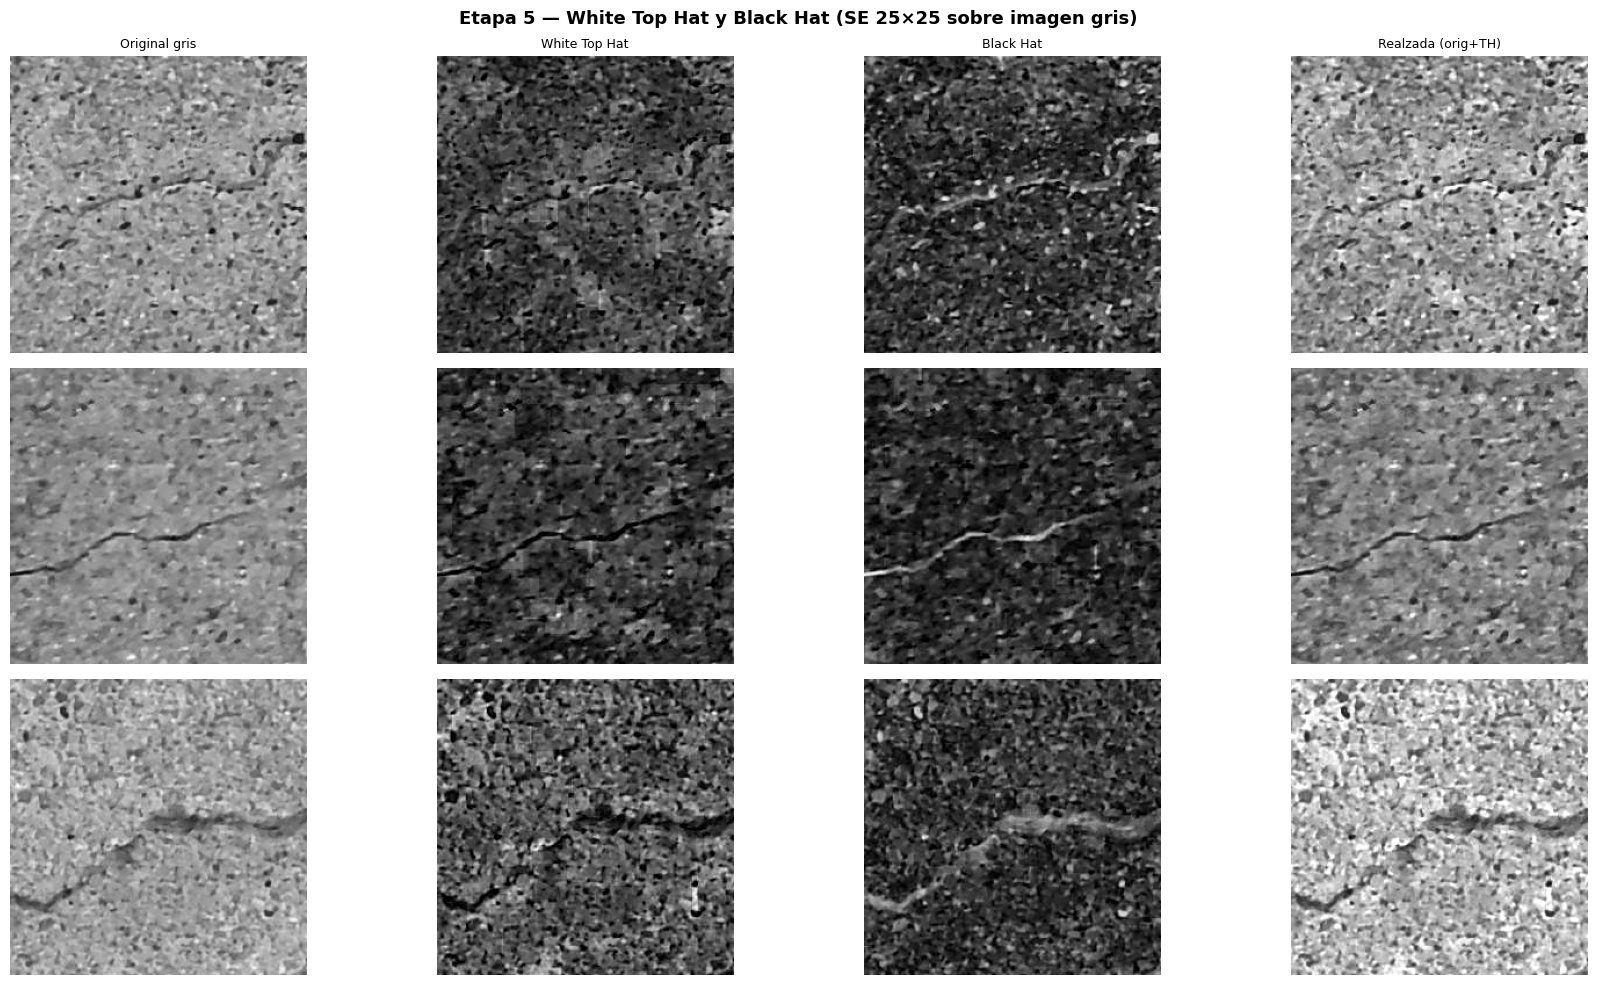

In [12]:
# ── Top Hat y Black Hat sobre imagen gris original ────────────────────────
SE_TH = cv2.getStructuringElement(cv2.MORPH_RECT, (25, 25))
tophat_imgs   = {}
blackhat_imgs = {}

fig, axes = plt.subplots(len(imgs_gray), 4, figsize=(18, 10))
fig.suptitle("Etapa 5 — White Top Hat y Black Hat (SE 25×25 sobre imagen gris)", fontsize=13, fontweight="bold")

for fila, (nombre, gray) in enumerate(imgs_gray.items()):
    tophat   = cv2.morphologyEx(gray, cv2.MORPH_TOPHAT,   SE_TH)
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, SE_TH)
    realzada = cv2.add(gray, tophat)   # original + Top Hat = refuerza estructuras claras

    tophat_imgs[nombre]   = tophat
    blackhat_imgs[nombre] = blackhat

    for col, (titulo, img) in enumerate([
        ("Original gris",         gray),
        ("White Top Hat",         tophat),
        ("Black Hat",             blackhat),
        ("Realzada (orig+TH)",    realzada),
    ]):
        axes[fila, col].imshow(img, cmap="gray")
        if fila == 0: axes[fila, col].set_title(titulo, fontsize=9)
        axes[fila, col].axis("off")
    axes[fila, 0].set_ylabel(nombre, fontsize=8)

plt.tight_layout()
plt.savefig("fig_05_tophat.png", dpi=150, bbox_inches="tight")
plt.show()


---
## Sección 6 — Métricas Comparativas

El análisis visual necesita respaldo cuantitativo.

| Métrica | Qué mide |
|---|---|
| **Contraste (std)** | Dispersión de intensidades — mayor = más contraste local |
| **PSNR** | Fidelidad respecto al original — menor PSNR entre original y Top Hat = mayor diferencia introducida |
| **% área detectada** | Fracción de píxeles clasificados como grieta/borde |

Un Top Hat efectivo **debe aumentar el contraste** de la región de grieta respecto al fondo.


In [13]:
# ── Tabla de métricas ─────────────────────────────────────────────────────
print(f"{'Imagen':<30} {'Cont.orig':>10} {'Cont.k7':>10} {'Cont.TH':>10} {'PSNR(blur)':>12} {'%borde Otsu':>12} {'%borde morf':>12}")
print("-" * 100)

for nombre in imgs_gray:
    gray  = imgs_gray[nombre]
    blur  = suavizadas[nombre][K_SEL]
    bin_  = binarias[nombre]
    morf  = morfologicas[nombre]
    th    = tophat_imgs[nombre]

    psnr_blur = psnr(gray, blur, data_range=255)
    pct_otsu  = bin_.mean() / 255 * 100
    pct_morf  = morf.mean() / 255 * 100

    print(f"{nombre:<30} {gray.std():>10.2f} {blur.std():>10.2f} {th.std():>10.2f} "
          f"{psnr_blur:>12.2f} {pct_otsu:>12.2f}% {pct_morf:>12.2f}%")


Imagen                          Cont.orig    Cont.k7    Cont.TH   PSNR(blur)  %borde Otsu  %borde morf
----------------------------------------------------------------------------------------------------
Grieta sutil (001-130)              19.77      14.00      20.56        29.31        24.19%         2.82%
Grieta visible (001-145)            14.58      11.16      14.13        33.28        21.86%         3.55%
Grieta ramificada (010-123)         20.30      15.24      18.75        29.65        31.66%         3.39%


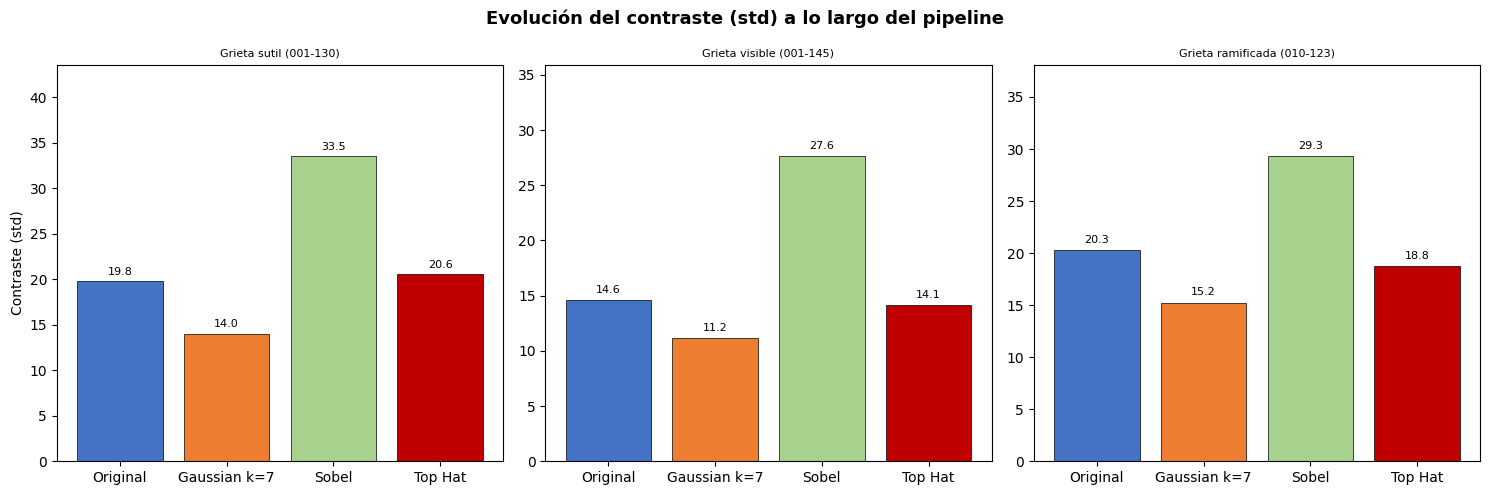

In [14]:
# ── Gráfico: evolución del contraste a lo largo del pipeline ──────────────
etapas  = ["Original", "Gaussian k=7", "Sobel", "Top Hat"]
colores = ["#4472C4", "#ED7D31", "#A9D18E", "#C00000"]

fig, axes = plt.subplots(1, len(imgs_gray), figsize=(15, 5))
fig.suptitle("Evolución del contraste (std) a lo largo del pipeline", fontsize=13, fontweight="bold")

for col, (nombre, gray) in enumerate(imgs_gray.items()):
    blur  = suavizadas[nombre][K_SEL]
    sobel = bordes_sobel[nombre]
    th    = tophat_imgs[nombre]

    valores = [gray.std(), blur.std(), sobel.std(), th.std()]
    bars = axes[col].bar(etapas, valores, color=colores, edgecolor="black", linewidth=0.5)
    axes[col].set_title(nombre, fontsize=8)
    axes[col].set_ylim(0, max(valores) * 1.3)
    if col == 0: axes[col].set_ylabel("Contraste (std)")
    for bar, val in zip(bars, valores):
        axes[col].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                       f"{val:.1f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig("fig_06_contraste.png", dpi=150, bbox_inches="tight")
plt.show()


---
## Sección 7 — Panel resumen: pipeline completo de un vistazo

Material directo para la sección de Resultados del informe científico.


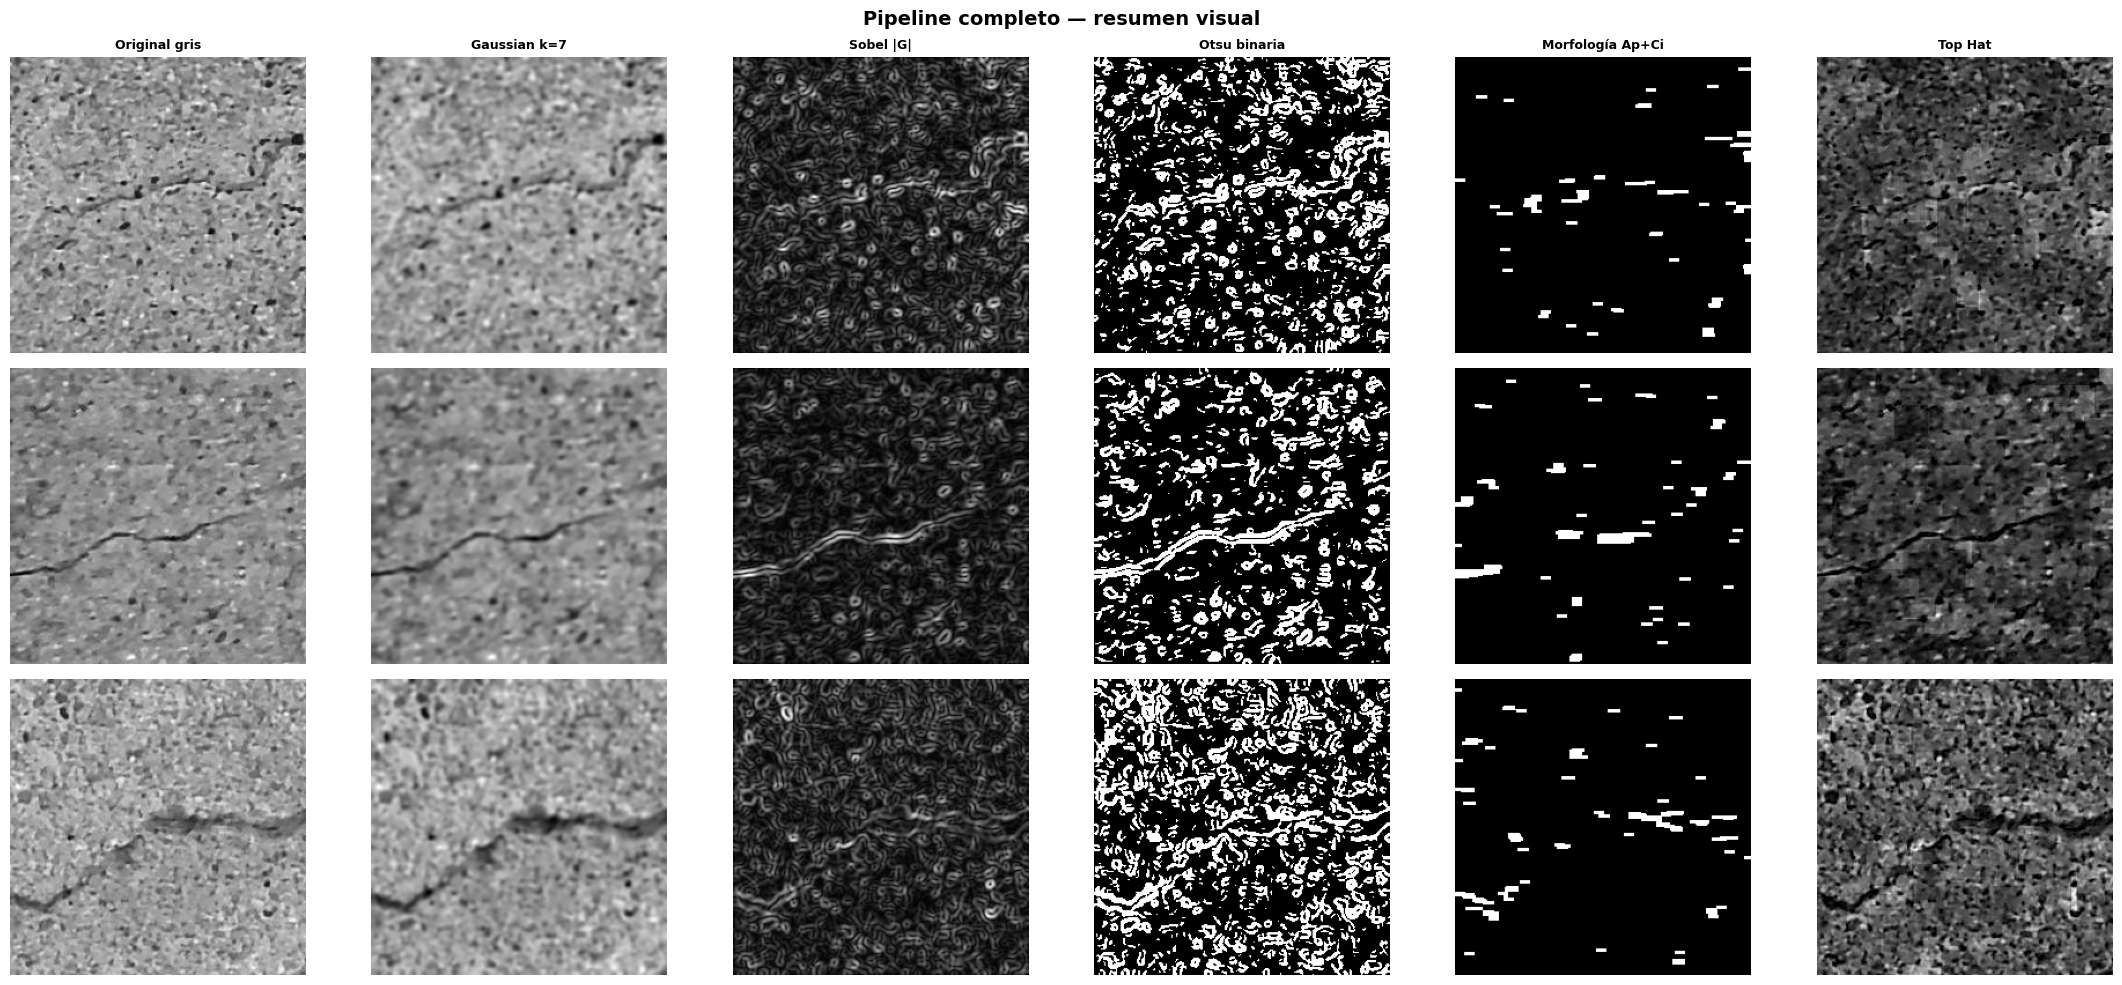

Pipeline completo generado.

Figuras generadas:
  fig_00_originales.png
  fig_01_gaussiano.png
  fig_01b_hist_gaussiano.png
  fig_02_bordes.png
  fig_03_otsu.png
  fig_04_morfologia_se.png
  fig_04b_morfologia_pipeline.png
  fig_05_tophat.png
  fig_06_contraste.png
  fig_07_pipeline_completo.png


In [15]:
# ── Panel final: 6 etapas x 3 imágenes ───────────────────────────────────
etapas_panel = [
    ("Original gris",       lambda n: imgs_gray[n]),
    ("Gaussian k=7",        lambda n: suavizadas[n][K_SEL]),
    ("Sobel |G|",           lambda n: bordes_sobel[n]),
    ("Otsu binaria",        lambda n: binarias[n]),
    ("Morfología Ap+Ci",    lambda n: morfologicas[n]),
    ("Top Hat",             lambda n: tophat_imgs[n]),
]

fig, axes = plt.subplots(len(imgs_gray), len(etapas_panel), figsize=(22, 10))
fig.suptitle("Pipeline completo — resumen visual", fontsize=14, fontweight="bold")

for col, (titulo, fn) in enumerate(etapas_panel):
    axes[0, col].set_title(titulo, fontsize=9, fontweight="bold")

for fila, nombre in enumerate(imgs_gray):
    axes[fila, 0].set_ylabel(nombre, fontsize=8)
    for col, (titulo, fn) in enumerate(etapas_panel):
        axes[fila, col].imshow(fn(nombre), cmap="gray")
        axes[fila, col].axis("off")

plt.tight_layout()
plt.savefig("fig_07_pipeline_completo.png", dpi=200, bbox_inches="tight")
plt.show()
print("Pipeline completo generado.")
print()
figuras = [
    "fig_00_originales.png",
    "fig_01_gaussiano.png",
    "fig_01b_hist_gaussiano.png",
    "fig_02_bordes.png",
    "fig_03_otsu.png",
    "fig_04_morfologia_se.png",
    "fig_04b_morfologia_pipeline.png",
    "fig_05_tophat.png",
    "fig_06_contraste.png",
    "fig_07_pipeline_completo.png",
]
print("Figuras generadas:")
for f in figuras:
    print(f"  {f}")
